#House Cost Prediction System

The ML function to predicting the cost of houses in a specific area by using the
features provided to us about that house


#Importing

In [29]:
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing #famous dataset call
cal_house = fetch_california_housing()


In [27]:
X=cal_house.data
y= cal_house.target
data=pd.DataFrame(X,columns=cal_house.feature_names)  #makes the labels of the table, the labels of the dataset (features)
data['Salesprice']=y  #makes a new column (target variable)
data.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Salesprice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


intresting thing was we get to segment the dataset before hand into target and features but thats the not the case always.

Preping for a situation where we don't know which is the target variable is mandatory

In [24]:
data.info()
data.describe()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Selesprice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


(20640, 9)

#EDA

In [25]:
data.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Selesprice,0


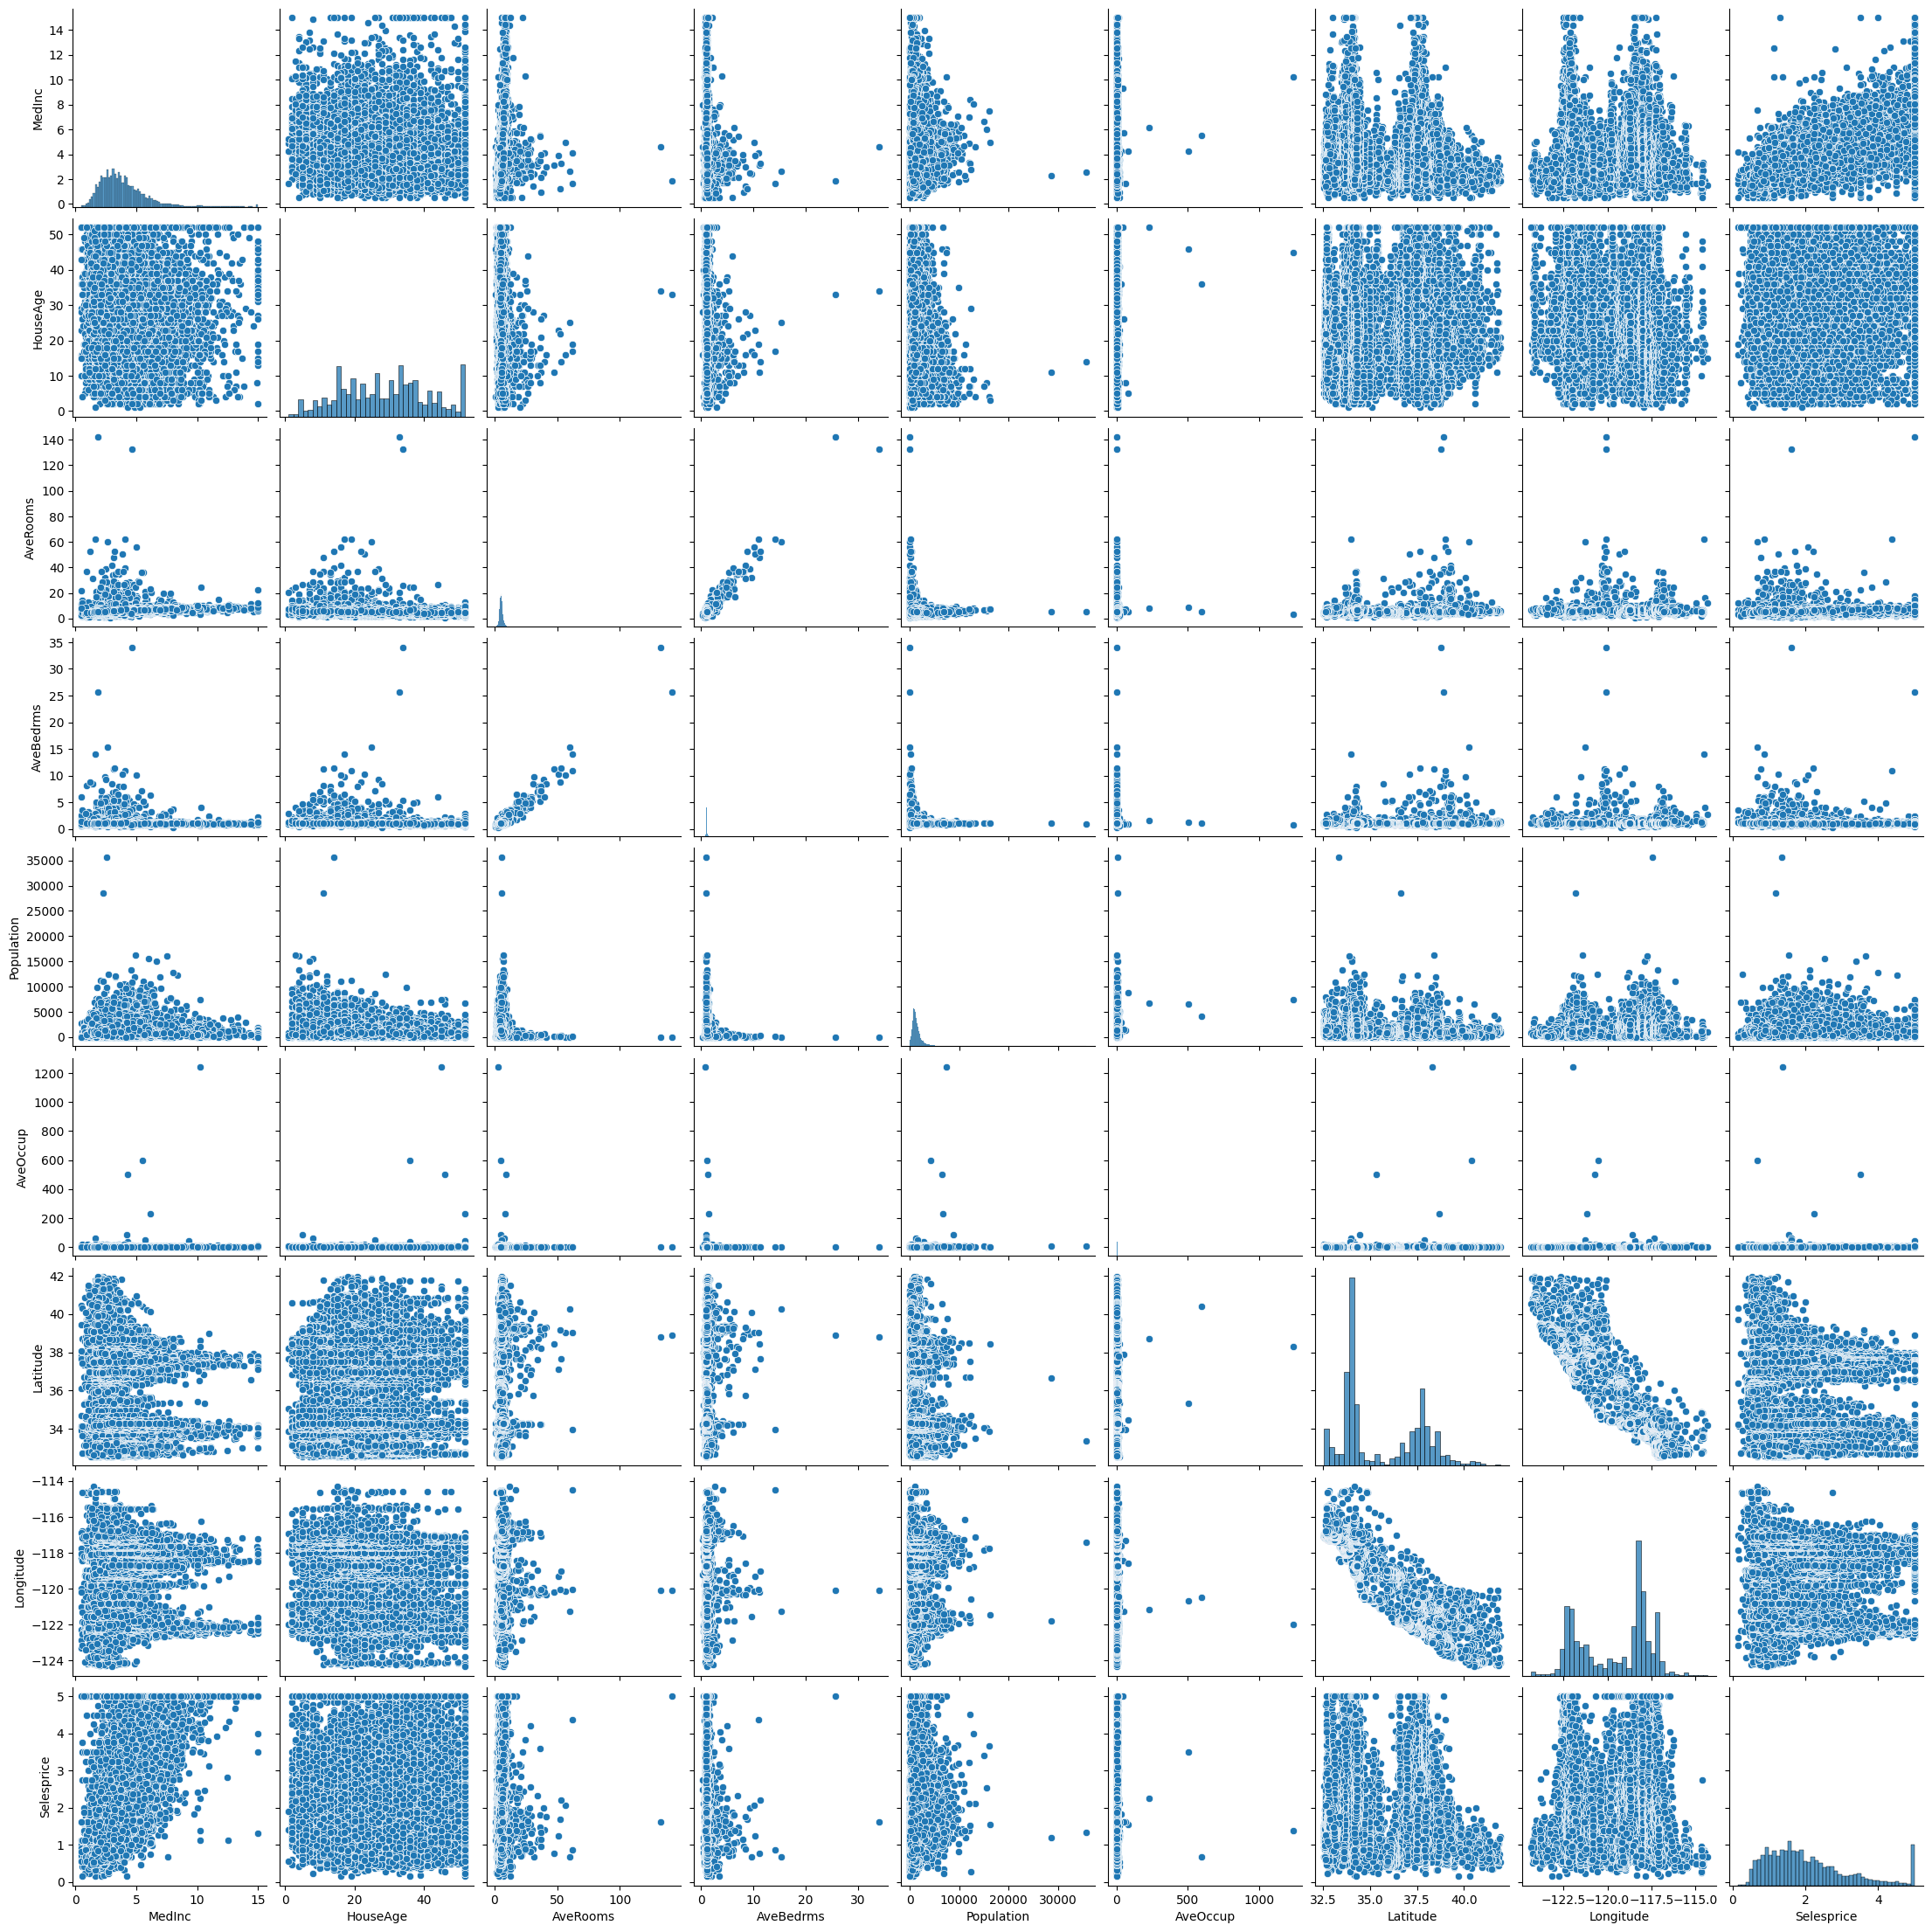

In [26]:
sns.pairplot(data,height=2.5) #plots graph baised on everything
plt.tight_layout()

/tmp/ipykernel_2637/749319311.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Salesprice'])


<Axes: xlabel='Salesprice', ylabel='Density'>

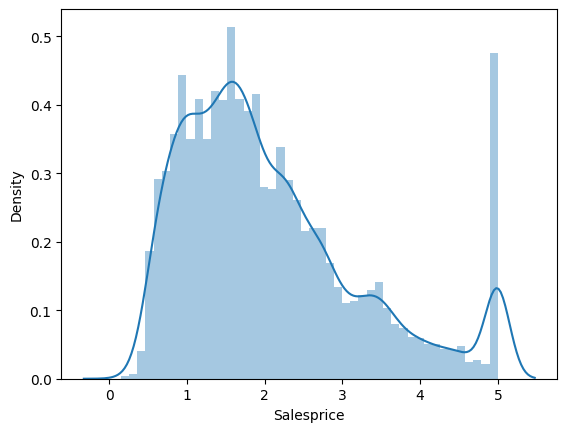

In [32]:
sns.distplot(data['Salesprice'])

Skewness and kurtosis are statistical measures that describe the shape of a probability distribution beyond its mean and variance. Skewness quantifies the asymmetry of a distribution, while kurtosis measures the "tailedness" or the presence of extreme outliers.

In [35]:
print("Skewness: %f" % data["Salesprice"].skew())
print("Kurtosis: %f" % data["Salesprice"].kurt()) #1, 1.6, 2.2, 5

Skewness: 0.977763
Kurtosis: 0.327870


<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2637/2691869152.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],loc='best') #shows state values on plt with symbols
/tmp/ipykernel_2637/2691869152.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Salesprice'],fit=norm)



 mu = 2.07 and sigma = 1.15



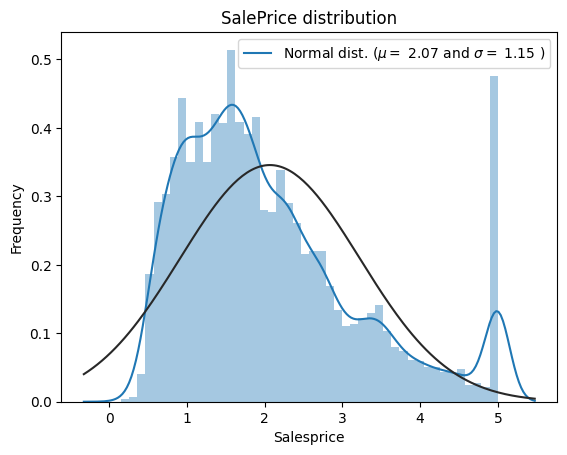

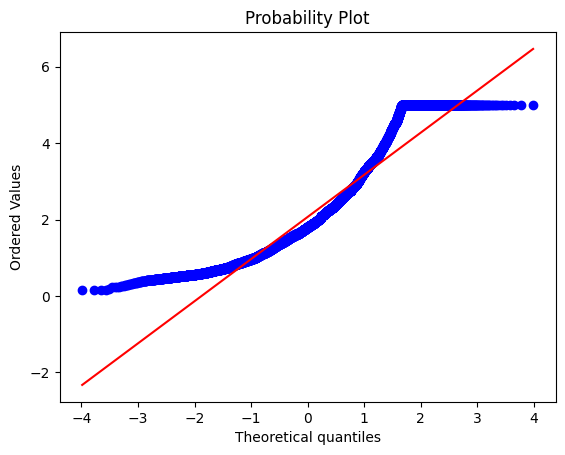

In [50]:
from scipy import stats
from scipy.stats import norm, skew #more statistics
sns.distplot(data['Salesprice'],fit=norm)
(mu,sigma)=norm.fit(data['Salesprice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],loc='best') #shows state values on plt with symbols
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

#QQ Plot
fig=plt.figure()
res=stats.probplot(data['Salesprice'],plot=plt) #probability distribution
plt.show()
#this one teaches about foreign quantiles

We see some deviation so we apply a transformation

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2637/3820821110.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],loc='best')
/tmp/ipykernel_2637/3820821110.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Salesprice'],fit=norm)



 mu = 0.71 and sigma = 0.17



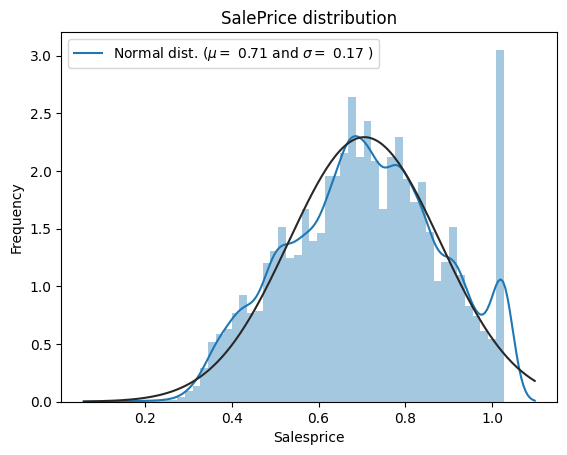

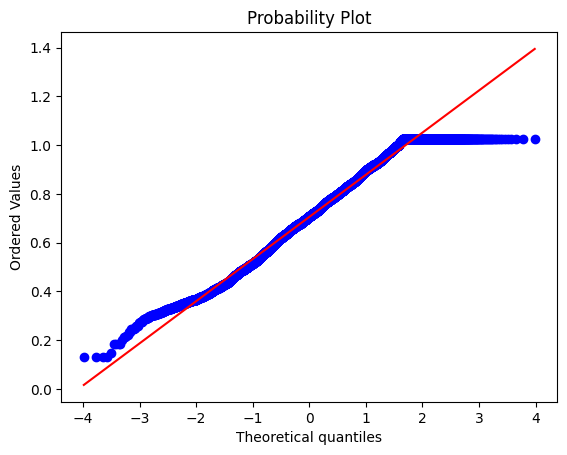

In [52]:
data['Salesprice']=np.log1p(data['Salesprice'])
sns.distplot(data['Salesprice'],fit=norm)
(mu,sigma)=norm.fit(data['Salesprice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

#QQ Plot
fig=plt.figure()
res=stats.probplot(data['Salesprice'],plot=plt)
plt.show()


You see more stailised distribution

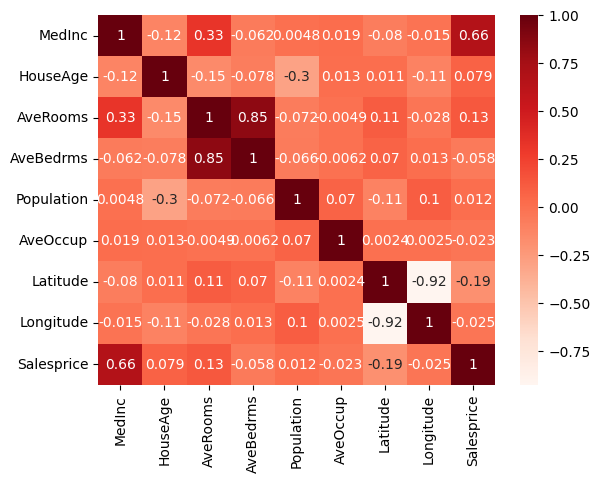

MedInc        0.66194
Salesprice    1.00000
Name: Salesprice, dtype: float64


In [65]:
cor=data.corr()
sns.heatmap(cor,annot=True,cmap=plt.cm.Reds)
plt.show()
cor_target=abs(cor["Salesprice"])
rel_features=cor_target[cor_target>0.29]
print(rel_features)

#Model Building

In [79]:
from sklearn.model_selection import train_test_split
x=data.drop("Salesprice",axis=1)
y=data["Salesprice"]
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)


In [80]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [84]:
predictions=lr.predict(x_test)
print("Actual value of house:",y_test[3])
print("Predicted price of house:",predictions[3])

Actual value of house: 0.9100934605104698
Predicted price of house: 0.8341920334678008


In [86]:
#for accuracy
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,predictions)
print("MSE:",mse)
rmse=np.sqrt(mse)


MSE: 0.012143861716243539


#Results

In [100]:
print("The Predicted Value for House 2 :", predictions[3])
print("The Actual Value for House 2 :", y_test[3])

The Predicted Value for House 2 : 0.8341920334678008
The Actual Value for House 2 : 0.9100934605104698
